In [1]:
# %% [markdown]
# # Evaluation: SAM3 Fish Count vs. Ground Truth Fish Count (Full Frame)

# %%
from collections import defaultdict
from dataclasses import dataclass
import gc
import gzip
import logging
import os
from pathlib import Path
import pickle
import re
from typing import Any, Dict, List, Optional, Tuple
import warnings
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# 1. LOGGING & WARNINGS SETUP
# ==============================================================================
warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("SAM3CountingEval")


# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================
@dataclass(frozen=True)
class EvalConfig:
    """Central configuration for dataset paths."""

    gt_labels_dir: Path = Path("../gt_labels_new_tofill")
    recordings_dir: Path = Path("../recordings_counted")
    masks_path: Path = Path("./cropped_outputs_raw_masks_compressed")
    cropped_frames_dir: Path = Path("../recordings_counted/cropped_frames")  # same frames SAM3 was run on
    yolo_model_path: Path = Path("../yolo/runs/segment/train-19/weights/best.pt")
    yolo_conf_threshold: float = 0.25
    #output_dir: Path = Path("./evaluation_sam3count_vs_gtcount_output")

    #def __post_init__(self):
    #    self.output_dir.mkdir(parents=True, exist_ok=True)


CONFIG = EvalConfig()
#logger.info(f"Output directory initialized: {CONFIG.output_dir.resolve()}")

In [2]:
# ==============================================================================
# 3. HELPER FUNCTIONS
# ==============================================================================
def load_raw_pickle(file_path: Path) -> Any:
    """Loads SAM3 output masks from .pkl, .zip, or .pkl.gz files."""
    if file_path.suffix == ".zip" or zipfile.is_zipfile(file_path):
        with zipfile.ZipFile(file_path, "r") as zf:
            pkl_name = next(n for n in zf.namelist() if n.endswith(".pkl"))
            with zf.open(pkl_name) as f:
                return pickle.load(f)
    elif file_path.suffix == ".gz" or str(file_path).endswith(".pkl.gz"):
        with gzip.open(file_path, "rb") as f:
            return pickle.load(f)
    else:
        with open(file_path, "rb") as f:
            return pickle.load(f)


def load_binary_mask(mask_path: Path) -> np.ndarray:
    """Loads and binarizes an .npy or .npz mask file."""
    data = np.load(mask_path)
    mask = (
        data[list(data.keys())[0]] if mask_path.suffix == ".npz" else data
    ).astype(np.uint8)

    if mask.ndim == 3:
        mask = mask.squeeze()

    return (mask > 0).astype(np.uint8)

In [3]:
# ==============================================================================
# 4. DATA EXTRACTION & COUNTING (GROUND TRUTH VS. SAM3)
# ==============================================================================
logger.info("Discovering video mapping text files...")

# Find all fishvideo mapping files directly in gt_labels_dir
txt_files = sorted(list(CONFIG.gt_labels_dir.glob("fishvideo*.txt")))
logger.info(
    f"Found {len(txt_files)} mapping files to evaluate: {[f.name for f in txt_files]}"
)

all_sam_files = list(CONFIG.masks_path.glob("*")) + list(
    CONFIG.masks_path.glob("*/*")
)
records = []

for txt_file in txt_files:
    video_prefix = txt_file.stem
    num_match = re.search(r"\d+", video_prefix)
    if not num_match:
        continue

    v_num = int(num_match.group(0))

    # Locate finished annotation directory
    finished_candidates = [
        CONFIG.gt_labels_dir / f"{video_prefix}_finished",
        CONFIG.gt_labels_dir / video_prefix,
        CONFIG.gt_labels_dir / f"fishvideo_{v_num}_finished",
    ]
    finished_folder = next((p for p in finished_candidates if p.exists()), None)

    if not finished_folder:
        logger.warning(
            f"Skipping {video_prefix}: Finished annotation directory not found."
        )
        continue

    # Read frame numbers directly from the mapping txt
    with open(txt_file, "r") as f:
        frame_numbers = [int(n) for n in re.findall(r"\d+", f.read())]

    # Collect Ground Truth mask files grouped by task_id
    all_mask_files = sorted(
        list(finished_folder.glob("*.npy"))
        + list(finished_folder.glob("*.npz"))
    )
    task_groups = defaultdict(lambda: defaultdict(list))
    for mf in all_mask_files:
        match = re.search(r"task-(\d+)", mf.name)
        if match:
            task_id = int(match.group(1))
            name_lower = mf.name.lower()
            if (
                "tag-fisch" in name_lower
                or "tag-fish-" in name_lower
                or "tag-fish." in name_lower
                or name_lower.endswith("-fish.npy")
            ):
                task_groups[task_id]["fish"].append(mf)

    sorted_task_ids = sorted(task_groups.keys())
    min_len = min(len(frame_numbers), len(sorted_task_ids))

    # Match SAM3 files for this video segment
    pattern = re.compile(
        rf".*video_?0*{v_num}_(\d+)_to_(\d+).*", re.IGNORECASE
    )
    sam_video_files = []
    for f in all_sam_files:
        m = pattern.search(f.name)
        if m:
            start_f = int(m.group(1))
            end_f = int(m.group(2))
            sam_video_files.append((f, start_f, end_f))

    file_to_frames = defaultdict(list)
    for frame_nr, task_id in zip(
        frame_numbers[:min_len], sorted_task_ids[:min_len]
    ):
        for s_file, s_start, s_end in sam_video_files:
            if s_start <= frame_nr <= s_end:
                file_to_frames[s_file].append((frame_nr, task_id, s_start))
                break

    # Load SAM3 masks into memory
    extracted_sam_masks_by_frame = {}
    for s_file, frame_info_list in file_to_frames.items():
        try:
            sam_data = load_raw_pickle(s_file)
            for frame_nr, task_id, s_start in frame_info_list:
                rel_idx = frame_nr - s_start
                frame_entry = None

                for key in (rel_idx, str(rel_idx), frame_nr, str(frame_nr)):
                    if key in sam_data:
                        frame_entry = sam_data[key]
                        break

                if frame_entry and isinstance(frame_entry, dict):
                    raw_masks = frame_entry.get("out_binary_masks", None)
                    if raw_masks is not None:
                        if hasattr(raw_masks, "cpu") and hasattr(
                            raw_masks, "numpy"
                        ):
                            raw_masks = raw_masks.cpu().numpy()
                        raw_masks = np.array(raw_masks)

                        frame_masks = []
                        for idx in range(len(raw_masks)):
                            m = raw_masks[idx]
                            if m.ndim == 3:
                                m = m.squeeze()
                            if m.ndim == 2 and m.sum() > 0:
                                frame_masks.append((m > 0).astype(np.uint8))
                        extracted_sam_masks_by_frame[frame_nr] = frame_masks

            del sam_data
            gc.collect()
        except Exception as e:
            logger.error(f"Error loading {s_file.name}: {e}")

    # Count GT vs SAM3 predictions per frame
    for frame_nr, task_id in zip(
        frame_numbers[:min_len], sorted_task_ids[:min_len]
    ):
        gt_fish_files = task_groups[task_id]["fish"]

        # Check 1: Missing Ground Truth fish masks
        if not gt_fish_files:
            logger.warning(
                f"[SKIP] {video_prefix} | Frame {frame_nr:04d} (Task-{task_id}): "
                f"No GT fish mask files found."
            )
            continue

        # Check 2: Missing SAM3 prediction masks
        if frame_nr not in extracted_sam_masks_by_frame:
            logger.warning(
                f"[SKIP] {video_prefix} | Frame {frame_nr:04d} (Task-{task_id}): "
                f"No SAM3 prediction masks found (Video ID: {v_num})."
            )
            continue

        # 1. Ground Truth Fish Count
        gt_count = 0
        for mf in gt_fish_files:
            m = load_binary_mask(mf)
            if m.sum() > 0:
                gt_count += 1

        # 2. SAM3 Fish Prediction Count
        pred_count = 0
        for m in extracted_sam_masks_by_frame[frame_nr]:
            if m.sum() > 0:
                pred_count += 1

        records.append(
            {
                "video": video_prefix,
                "frame": frame_nr,
                "task_id": task_id,
                "gt_count": gt_count,
                "pred_count": pred_count,
                "diff": pred_count - gt_count,
            }
        )

# Build DataFrame
df_counts = pd.DataFrame(records)
logger.info(f"Successfully evaluated frames: {len(df_counts)}")

# Compute summary metrics
if not df_counts.empty:
    mae = np.mean(np.abs(df_counts["diff"]))

    print("\n" + "=" * 65)
    print("           📊 SAM3 COUNTING EVALUATION SUMMARY")
    print("=" * 65)
    print(f"  • Total Evaluated Frames:       {len(df_counts):,}")
    print(f"  • Total Ground Truth Fish:      {df_counts['gt_count'].sum():,}")
    print(f"  • Total SAM3 Predicted Fish:    {df_counts['pred_count'].sum():,}")
    print(f"  • Mean Absolute Error (MAE):    {mae:.3f}")
    print("=" * 65 + "\n")

[15:14:58] [INFO] Discovering video mapping text files...
[15:14:58] [INFO] Found 14 mapping files to evaluate: ['fishvideo30.txt', 'fishvideo31.txt', 'fishvideo32.txt', 'fishvideo33.txt', 'fishvideo34.txt', 'fishvideo38.txt', 'fishvideo39.txt', 'fishvideo40.txt', 'fishvideo57.txt', 'fishvideo58.txt', 'fishvideo61.txt', 'fishvideo63.txt', 'fishvideo64.txt', 'fishvideo67.txt']
[15:20:08] [INFO] Successfully evaluated frames: 102



           📊 SAM3 COUNTING EVALUATION SUMMARY
  • Total Evaluated Frames:       102
  • Total Ground Truth Fish:      2,479
  • Total SAM3 Predicted Fish:    2,909
  • Mean Absolute Error (MAE):    5.333



In [4]:
# ==============================================================================
# 5. YOLO COUNTING ON THE SAME FRAMES
# ==============================================================================
import torch
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Loading YOLO model from: {CONFIG.yolo_model_path} ({device})")
yolo_model = YOLO(str(CONFIG.yolo_model_path))

yolo_counts = []
for _, row in df_counts.iterrows():
    img_path = (
        CONFIG.cropped_frames_dir
        / f"frames_{row['video']}_cropped"
        / f"{int(row['frame']):04d}.jpg"
    )
    img = cv2.imread(str(img_path))
    if img is None:
        logger.warning(f"[SKIP] {row['video']} | Frame {int(row['frame']):04d}: {img_path} not found.")
        yolo_counts.append(np.nan)
        continue

    result = yolo_model.predict(
        source=img,
        conf=CONFIG.yolo_conf_threshold,
        verbose=False,
        device=device,
    )[0]
    yolo_counts.append(0 if result.boxes is None else len(result.boxes))

df_counts["yolo_count"] = yolo_counts
df_counts["yolo_diff"] = df_counts["yolo_count"] - df_counts["gt_count"]

# Compute summary metrics
if not df_counts.empty:
    print("\n" + "=" * 65)
    print("           📊 SAM3 VS. YOLO COUNTING SUMMARY")
    print("=" * 65)
    print(f"  • Evaluated Frames:             {len(df_counts):,}")
    print(f"  • Total Ground Truth Fish:      {df_counts['gt_count'].sum():,}")
    print(f"  • Total SAM3 Predicted Fish:    {df_counts['pred_count'].sum():,}")
    print(f"  • Total YOLO Predicted Fish:    {int(df_counts['yolo_count'].sum()):,}")
    print(f"  • MAE SAM3:                     {np.mean(np.abs(df_counts['diff'])):.3f}")
    print(f"  • MAE YOLO:                     {np.nanmean(np.abs(df_counts['yolo_diff'])):.3f}")
    print("=" * 65 + "\n")


[15:20:11] [INFO] Loading YOLO model from: ../yolo/runs/segment/train-19/weights/best.pt (cuda)



           📊 SAM3 VS. YOLO COUNTING SUMMARY
  • Evaluated Frames:             102
  • Total Ground Truth Fish:      2,479
  • Total SAM3 Predicted Fish:    2,909
  • Total YOLO Predicted Fish:    3,020
  • MAE SAM3:                     5.333
  • MAE YOLO:                     5.794



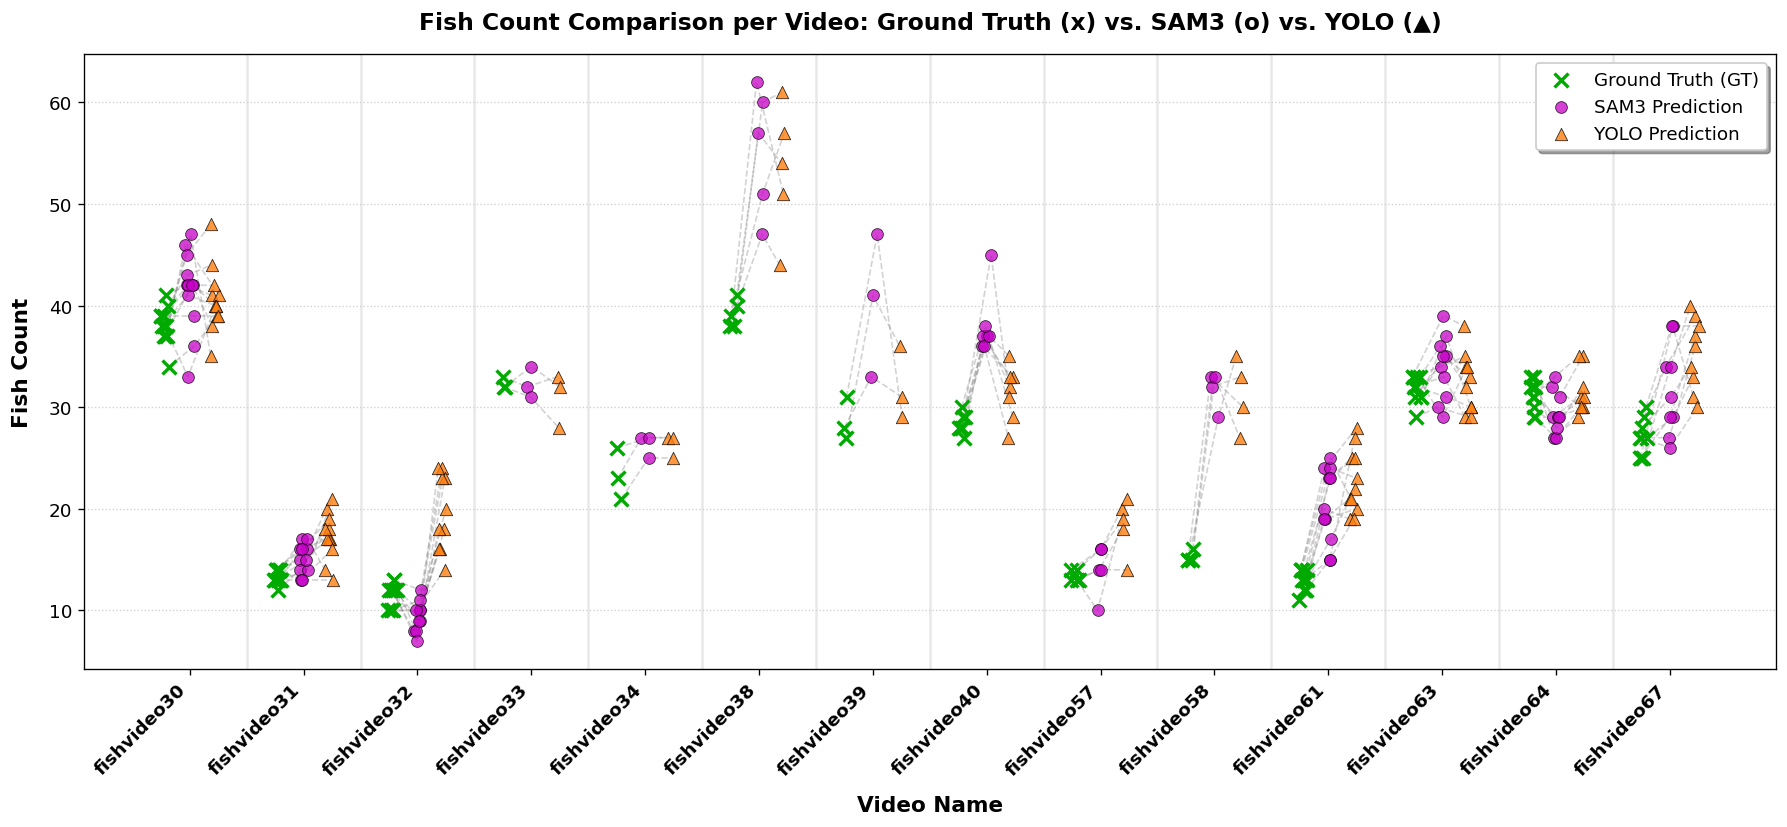

In [5]:
# ==============================================================================
# 6. PLOT: FISH COUNT PER VIDEO (GROUND TRUTH VS. SAM3 VS. YOLO PREDICTIONS)
# ==============================================================================
# 1. Sort videos naturally by their numeric ID (e.g., fishvideo30 -> fishvideo67)
unique_videos = sorted(
    df_counts["video"].unique(),
    key=lambda v: (
        int(re.findall(r"\d+", v)[0]) if re.findall(r"\d+", v) else v
    ),
)
video_to_x = {v: i for i, v in enumerate(unique_videos)}

# 2. Setup plot dimensions
plt.figure(figsize=(15, 7), dpi=120)
np.random.seed(42)  # For reproducible jitter

# Plot paired data points for each frame
for idx, row in df_counts.iterrows():
    x_base = video_to_x[row["video"]]

    # Add slight random horizontal jitter to separate overlapping counts
    jitter_gt = np.random.uniform(-0.04, 0.04)
    jitter_pred = np.random.uniform(-0.04, 0.04)
    jitter_yolo = np.random.uniform(-0.04, 0.04)

    x_gt = x_base - 0.22 + jitter_gt
    x_pred = x_base + jitter_pred
    x_yolo = x_base + 0.22 + jitter_yolo

    y_gt = row["gt_count"]
    y_pred = row["pred_count"]
    y_yolo = row["yolo_count"]

    # Thin connector line showing count delta per frame
    plt.plot(
        [x_gt, x_pred, x_yolo],
        [y_gt, y_pred, y_yolo],
        color="gray",
        alpha=0.35,
        linestyle="--",
        linewidth=1,
    )

    # Plot GT (Green Cross)
    plt.scatter(
        x_gt,
        y_gt,
        color="#00aa00",
        marker="x",
        s=70,
        linewidths=2,
        zorder=3,
        label="Ground Truth (GT)" if idx == 0 else "",
    )

    # Plot SAM3 Prediction (Magenta Circle)
    plt.scatter(
        x_pred,
        y_pred,
        color="#c800c8",
        marker="o",
        s=50,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.5,
        zorder=3,
        label="SAM3 Prediction" if idx == 0 else "",
    )

    # Plot YOLO Prediction (Orange Triangle)
    plt.scatter(
        x_yolo,
        y_yolo,
        color="#ff7f0e",
        marker="^",
        s=55,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        zorder=3,
        label="YOLO Prediction" if idx == 0 else "",
    )

# 3. Aesthetics & Axis Configuration
plt.xticks(
    ticks=range(len(unique_videos)),
    labels=unique_videos,
    rotation=45,
    ha="right",
    fontsize=11,
    fontweight="bold",
)
plt.yticks(fontsize=11)
plt.xlabel("Video Name", fontsize=13, fontweight="bold", labelpad=10)
plt.ylabel("Fish Count", fontsize=13, fontweight="bold", labelpad=10)
plt.title(
    "Fish Count Comparison per Video: Ground Truth (x) vs. SAM3 (o) vs. YOLO (▲)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(frameon=True, fontsize=11, loc="upper right", shadow=True)

# Add subtle vertical separators between videos
for x in range(len(unique_videos) - 1):
    plt.axvline(x=x + 0.5, color="lightgray", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.show()
